In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)

import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [2]:
RUN_ID = 'u_per_min10_1'
DT = 1
Q0 = 17921.57581 
SAVE  = False
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [3]:
def prepare_data(data, index = 0, test = False):
    if test:
        i = index + int(0.8*len(data['trajectory'].unique()))
    else:
        i = index

    trajs = data[data['trajectory'] == i].reset_index(drop=True)

    return trajs

In [4]:


def read_data(file_name):
    df = pd.read_csv(
        f"symbol_data/{file_name}.txt",
        sep=',',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = read_data(path)


data = data[data['u_per'] > 5]

data['k'] = data['k'] * 100

k_ref = data['k'].mean() 
print(f'k_ref: {k_ref:.5f} GN/mm')
REF_VALUES = {
    'R1': 0.01,
    'C1': 1000,
    'k': k_ref}

display(data.head())

N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

k_ref: 3.09776 GN/mm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.008427,774.54987,0.008969,3.212417
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.008426,774.55980,0.008969,3.212486
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.008426,774.56970,0.008969,3.212555
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.008426,774.57965,0.008969,3.212625
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.008426,774.58950,0.008969,3.212694


Number of trajectories: 82


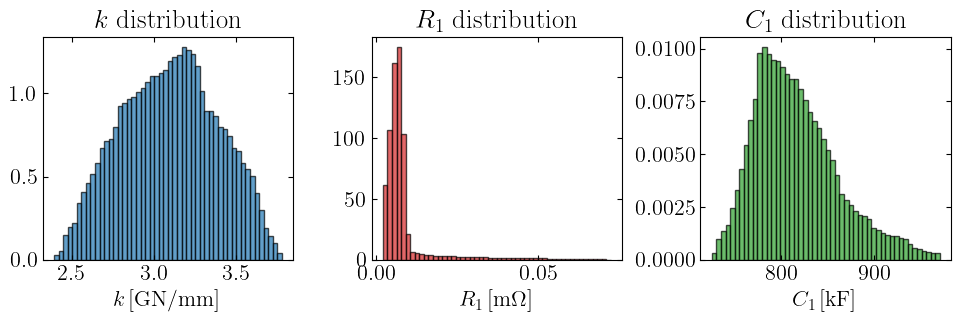

In [5]:
f,ax = plt.subplots(1,3, figsize=(10,3.5))
ax[0].hist(data['k'], bins=50, color=colors[0], alpha=0.7,edgecolor='black', density=True)
ax[0].set_title(r'$k$ distribution')
ax[0].set_xlabel(r'$k\,$[GN/mm]')

ax[1].hist(data['R1'], bins=50, color=colors[1], alpha=0.7,edgecolor='black', density=True)
ax[1].set_title(r'$R_1$ distribution')
ax[1].set_xlabel(r'$R_1\,$[m$\Omega$]')

ax[2].hist( data['C1'], bins=50, color=colors[2], alpha=0.7,edgecolor='black', density=True)
ax[2].set_title(r'$C_1$ distribution')
ax[2].set_xlabel(r'$C_1\,$[kF]')
plt.tight_layout()


## The sampled terrain

In [6]:
# u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C','trajectory']]
# plt.xlabel('C-rate [Ah]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

In [7]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 1e5:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds], Y_R1[inds], Y_C1[inds], Y_k[inds]

In [8]:
split_train = int(data['trajectory'].max() * 0.8)
data_train = data[data['trajectory'] <= split_train]
data_test = data[data['trajectory'] > split_train]
trajs_train = prepare_data(data_train)
trajs_test = prepare_data(data_test)

X_train, YR1_train, YC_train, Yk_train = get_XY(data_train)

X_test,  YR1_test, YC_test, Yk_test = get_XY(data_test)


# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 2th data point for symbolic regression, total points: 64752
Using every 1th data point for symbolic regression, total points: 10040


In [9]:
def print_models(df_model):
    for i in range(len(df_model)):
        print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
        print(f"Equation: {df_model['equation'][i]}\n")

def print_best_model(model, model_index = None):
    best = model.get_best()
    display(Math(f'\\LARGE {model.latex(model_index)}'))
    display(Math(r'\LARGE $x_0 = \mathrm{{c}}$-rate$'))
    display(Math(r'\LARGE $x_1 = \Delta u / L_{{tot}}$'))
    display(Math(r'\LARGE $x_2 = \mathrm{SOC}$'))
    print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [10]:
# Parity plot
def pareto_plot(model):
    df_model = model.equations_
    best = model.get_best()
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
    plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
    plt.xlabel('Complexity')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.title('Model Complexity vs Loss')
    plt.legend()
    plt.show()

def parity_plot(element,model, X_test = X_test, Yk_test = Yk_test, YC_test = YC_test, Y_R1_test = YR1_test):
    if element == 'R1':
        Y_test = YR1_test
    elif element == 'k':
        Y_test = Yk_test
    elif element == 'C1':
        Y_test = YC_test

    Y_pred = model.predict(X_test)
    plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
    plt.xlabel(f'Actual ${element}$ [a.u.]')
    plt.ylabel(f'Predicted ${element}$ [a.u.]')
    plt.show()

def save_expressions(df_model, element):
    df_model.to_csv(f'sr_models/model_{element}.csv', index=False)

# $k = f_k(i,d,\mathrm{SOC})$

In [11]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


In [12]:
df_model_k = model_k.equations_

In [13]:
print_models(df_model_k)

Model 0: Complexity=1, Loss=0.009342502
Equation: 1.0002067

Model 1: Complexity=3, Loss=0.008143803
Equation: x2 ^ -0.032076523

Model 2: Complexity=4, Loss=0.006698152
Equation: sqrt(log(log(x1)))

Model 3: Complexity=5, Loss=0.0039002441
Equation: (1.008065 ^ x1) - 0.14457507

Model 4: Complexity=6, Loss=0.0021098715
Equation: 1.1865889 - sqrt(x2 / x1)

Model 5: Complexity=7, Loss=0.0019370286
Equation: 1.2873508 - ((x2 / x1) ^ 0.3673562)

Model 6: Complexity=8, Loss=0.0013401473
Equation: (1.0349382 - (x2 / x1)) ^ sqrt(x1)

Model 7: Complexity=9, Loss=0.00084756175
Equation: (1.0061299 - (x2 / (x1 ^ 1.603518))) ^ x1

Model 8: Complexity=10, Loss=0.0007474674
Equation: sqrt((1.0137987 - (x2 / (x1 ^ 1.3063828))) ^ x1)

Model 9: Complexity=11, Loss=0.0006057644
Equation: (1.0076826 - (x2 / (x1 ^ 1.4913211))) ^ (x1 + -2.5516543)

Model 10: Complexity=13, Loss=0.00036094728
Equation: (((0.5058124 ^ x1) - (x2 / (x1 ^ 1.5454484))) + 1.0065641) ^ x1

Model 11: Complexity=15, Loss=0.0003537

In [14]:
print_best_model(model_k)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (0.5058124**x1 + 1.0065641 - x2/(x1**1.5454484))**x1
Loss: 0.00036094728
Best model complexity: 13


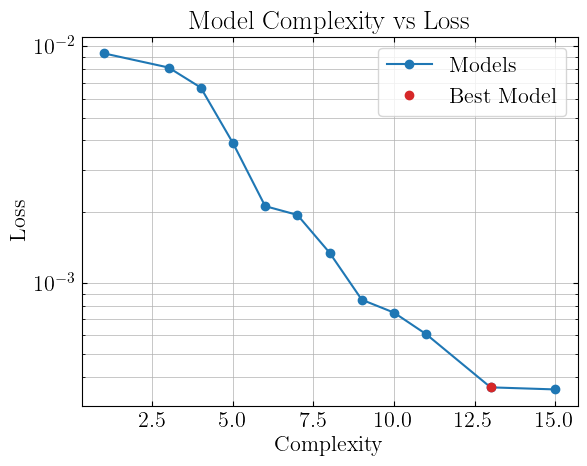

In [15]:
pareto_plot(model_k)

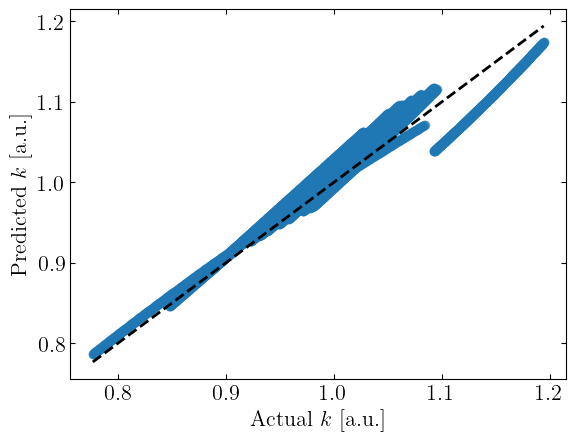

In [16]:
parity_plot('k',model_k)

# $R_1 = f_R(i,u,\mathrm{SOC})$

In [17]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


In [18]:
df_model_R1 = model_R1.equations_

In [19]:
print_models(df_model_R1)

Model 0: Complexity=1, Loss=0.93120337
Equation: 0.90168715

Model 1: Complexity=3, Loss=0.2581018
Equation: 0.27093464 / x2

Model 2: Complexity=5, Loss=0.24458905
Equation: (0.24751201 / x2) + 0.15598682

Model 3: Complexity=6, Loss=0.17235634
Equation: cube(x2 ^ (x2 + -0.23578617))

Model 4: Complexity=7, Loss=0.10451819
Equation: ((2.6636908e-6 ^ x2) * 10.958316) + x2

Model 5: Complexity=9, Loss=0.047715914
Equation: (x0 * ((5.774938e-9 ^ x2) * 18.469128)) + x2

Model 6: Complexity=10, Loss=0.031291094
Equation: x2 + ((2.5393348e-7 ^ x2) * (sqrt(x0) * 14.22))

Model 7: Complexity=12, Loss=0.028582934
Equation: (((2.5393348e-7 ^ x2) * sqrt(x0 ^ 1.2371156)) * 14.22) + x2

Model 8: Complexity=13, Loss=0.023592988
Equation: x2 + (((3.9808162e-7 ^ x2) * 12.471219) * sqrt(x0 ^ sqrt(x0)))

Model 9: Complexity=14, Loss=0.022880884
Equation: ((2.5393348e-7 ^ x2) * (sqrt(x0 ^ (x0 ^ 0.3173468)) * 14.22)) + x2

Model 10: Complexity=15, Loss=0.020577561
Equation: x2 + ((-0.03761718 + (14.22 * 

In [20]:
print_best_model(model_R1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 12.471219*3.9808162e-7**x2*sqrt(x0**(sqrt(x0))) + x2
Loss: 0.023592988
Best model complexity: 13


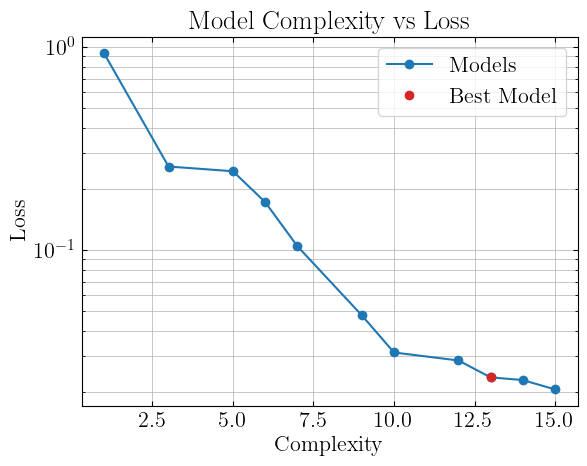

In [21]:
pareto_plot(model_R1)

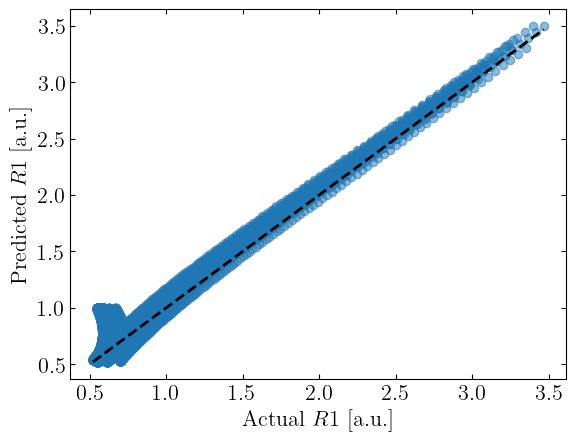

In [22]:
parity_plot('R1',model_R1)

In [23]:
#df_model_R1.to_csv('model_R1.csv', index=False)
#df_model_C1.to_csv('model_C1.csv', index=False)

# $C_1 = f_C(i,u,\mathrm{SOC})$

In [24]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


In [25]:
df_model_C1 = model_C1.equations_

In [26]:
print_models(df_model_C1)

Model 0: Complexity=1, Loss=0.001973349
Equation: 0.82013243

Model 1: Complexity=3, Loss=0.0014216037
Equation: x1 ^ -0.07287525

Model 2: Complexity=4, Loss=0.0010725256
Equation: 0.89490706 ^ exp(x2)

Model 3: Complexity=5, Loss=0.0008993454
Equation: 0.90767276 ^ exp(sqrt(x2))

Model 4: Complexity=6, Loss=0.00065851194
Equation: (x1 ^ -0.040732432) ^ exp(x2)

Model 5: Complexity=7, Loss=0.00036840353
Equation: (x1 ^ -0.046538904) / (1.1483161 ^ x2)

Model 6: Complexity=8, Loss=0.00036830318
Equation: (x1 ^ -0.04591551) / sqrt(1.3239268 ^ x2)

Model 7: Complexity=9, Loss=0.0002898241
Equation: (0.85427296 ^ (x2 + 1.0270791)) + (x1 ^ -1.2767483)

Model 8: Complexity=10, Loss=0.00027212343
Equation: ((square(x0) + x1) ^ -0.082506284) ^ sqrt(sqrt(x2))

Model 9: Complexity=11, Loss=0.00019867328
Equation: ((x0 + x1) ^ -1.0876217) + (0.72667277 ^ sqrt(sqrt(x2)))

Model 10: Complexity=12, Loss=0.00014727085
Equation: (0.72813255 ^ sqrt(sqrt(x2))) + ((x1 + square(x0)) ^ -1.0642812)

Model 

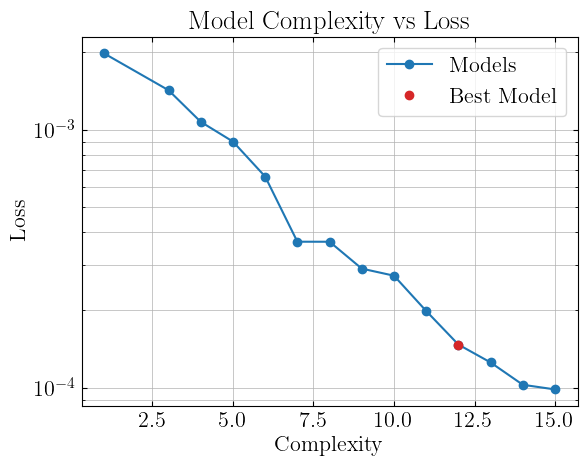

In [27]:
pareto_plot(model_C1)

In [28]:
print_best_model(model_C1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.72813255**(x2**(1/4)) + (x0**2 + x1)**(-1.0642812)
Loss: 0.00014727085
Best model complexity: 12


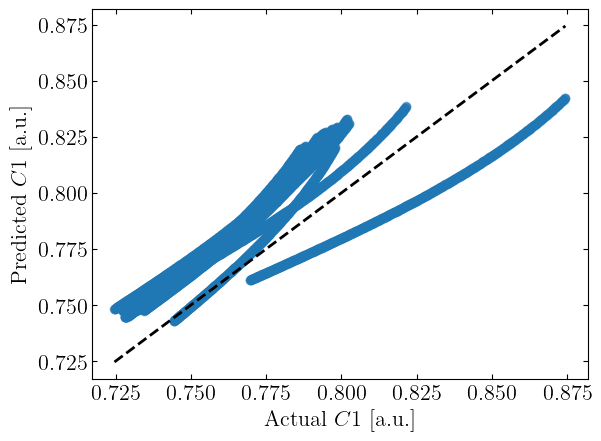

In [29]:
parity_plot('C1', model_C1)

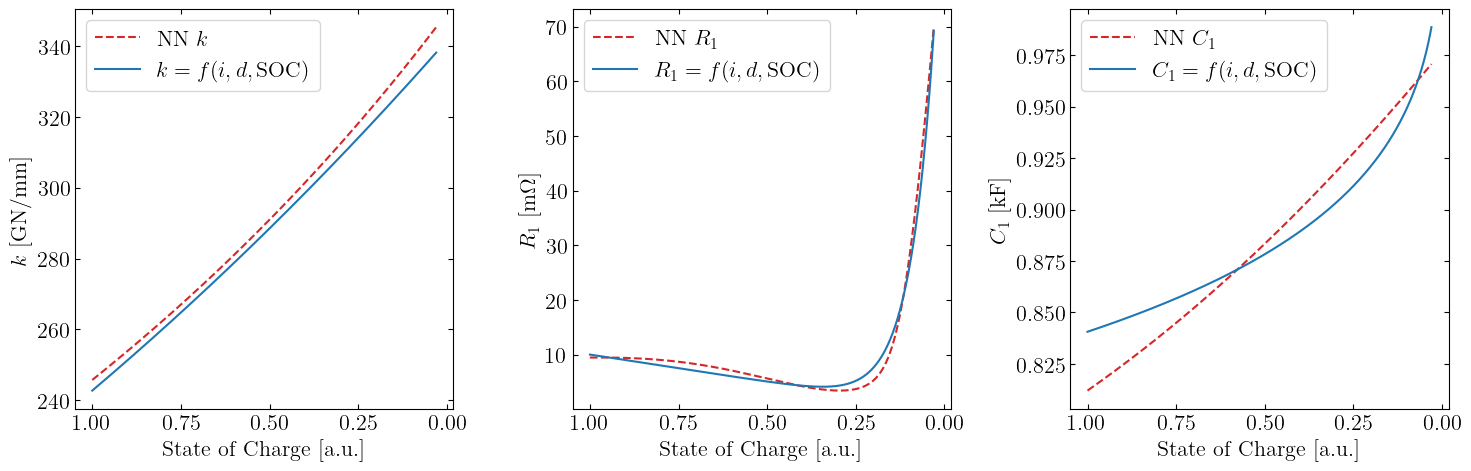

In [30]:
def plot_trajs_SOC(data = data, ind = 0, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    tr = prepare_data(data, index = ind, test=test)
    X = tr[['C', 'u_per', 'soc']].values
    Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    f,ax = plt.subplots(1,3, figsize=(15,5))
    ax[0].plot(tr['soc'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    ax[0].plot(tr['soc'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[1].plot(tr['soc'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    ax[1].plot(tr['soc'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[2].plot(tr['soc'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    ax[2].plot(tr['soc'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    for a in ax:
        a.set_xlabel('State of Charge [a.u.]')
        a.legend()
        a.invert_xaxis()
    ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 

    plt.tight_layout()
    plt.savefig('symbolic_traj_test.pdf')

plot_trajs_SOC(test = False, ind = 4)

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required.

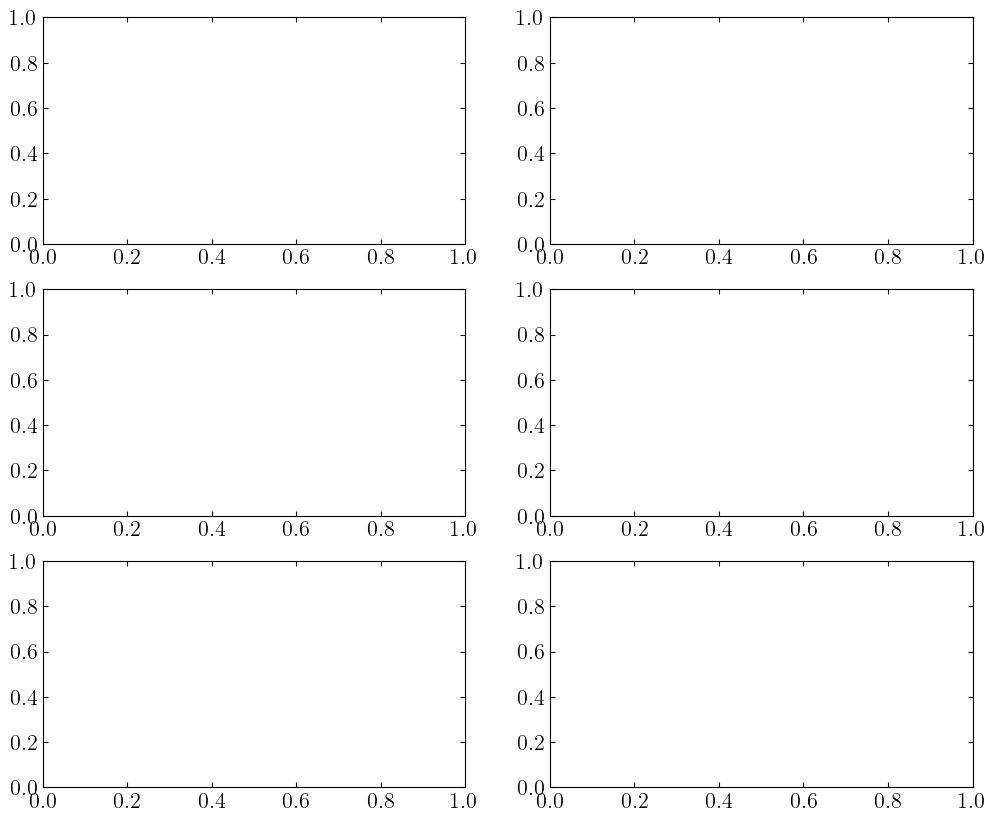

In [31]:
def plot_trajs_C_d(data = data, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    f,axs = plt.subplots(3,2, figsize=(12,10))
    
    train_index = int(0.8 * N_TRAJS )
    test_index = int(N_TRAJS - train_index)
    if test:
        ind = test_index
    else:
        ind = train_index
    i=0
    k_pred = np.zeros((ind,3)); R1_pred = np.zeros((ind,3)); C1_pred = np.zeros((ind,3))
    k_true = np.zeros((ind,3)); R1_true = np.zeros((ind,3)); C1_true = np.zeros((ind,3))
    X_vals = np.zeros((ind,2))    
    while i < ind:
        tr = prepare_data(data, index = i, test=test)
        X = tr[['C', 'u_per', 'soc']].values
        Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
        YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
        YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
        
        k_pred[i,0] = Yk_pred.mean(); R1_pred[i,0] = YR1_pred.mean(); C1_pred[i,0] = YC_pred.mean()
        k_pred[i,1] = Yk_pred.min(); R1_pred[i,1] = YR1_pred.min(); C1_pred[i,1] = YC_pred.min()
        k_pred[i,2] = Yk_pred.max(); R1_pred[i,2] = YR1_pred.max(); C1_pred[i,2] = YC_pred.max()

        k_true[i,0] = tr['k'].mean() * 100; R1_true[i,0] = tr['R1'].mean() * 1000; C1_true[i,0] = tr['C1'].mean() / 1000
        k_true[i,1] = tr['k'].min() * 100; R1_true[i,1] = tr['R1'].min() * 1000; C1_true[i,1] = tr['C1'].min() / 1000
        k_true[i,2] = tr['k'].max() * 100; R1_true[i,2] = tr['R1'].max() * 1000; C1_true[i,2] = tr['C1'].max() / 1000
        X_vals[i,0] = X[0,0]; X_vals[i,1] = X[0,1]
        i += 1

    for j in range(len(axs[0,:])):
        ax = axs[:,j]
        x = X_vals[:,j]
        ax[0].scatter(x, k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[0].scatter(x, k_true[:,0], label=r'NN $k$',  color=colors[1], alpha=0.7)
        #ax[0].plot(x, k_true[:,1] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].plot(x, k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].fill_between(x, k_true[:,1] * X_vals[:,1], k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.2, label='NN range')
        #ax[1].fill_between(x, R1_true[:,1] , R1_true[:,2], color=colors[1], alpha=0.2, label='NN range')
        #ax[2].fill_between(x, C1_true[:,1], C1_true[:,2], color=colors[1], alpha=0.2, label='NN range')

        ax[1].scatter(x, R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[1].scatter(x, R1_true[:,0], label=r'NN $R_1$',  color=colors[1], alpha=0.7)
        ax[2].scatter(x, C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
        ax[2].scatter(x, C1_true[:,0], label=r'NN $C_1$', color=colors[1], alpha=0.7)
        ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 
        
        ax[0].legend(); ax[1].legend(); ax[2].legend()
    for a in axs[:,0]:
        a.set_xlabel('C-rate [a.u.]')
    for a in axs[:,1]:
        a.set_xlabel(r'$\Delta u / L_{tot}$ [a.u.]')
    # for tr in test_trajs:
    #     X = tr[['C', 'u_per', 'soc']].values
    #     Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    #     YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    #     YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    #     f,ax = plt.subplots(1,3, figsize=(15,5))
    #     ax[0].plot(tr['C'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    #     ax[0].plot(tr['C'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[1].plot(tr['C'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    #     ax[1].plot(tr['C'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[2].plot(tr['C'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    #     ax[2].plot(tr['C'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    #     for a in ax:
    #         a.set_xlabel('C-rate [a.u.]')
    #         a.legend()
    #         a.invert_xaxis()
        
            
         
    plt.tight_layout()

    plt.show()
    f,ax = plt.subplots(1,3, figsize=(15,4))
    ax[0].scatter(X_vals[:,0],X_vals[:,1],c= k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',cmap = 'Blues')
    ax[0].set_xlabel('C-rate [a.u.]')
    ax[0].set_ylabel(r'$k$ [GN/mm]')
    ax[0].legend()
    ax[1].scatter(X_vals[:,0],X_vals[:,1],c= R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',cmap = 'Greens')
    ax[1].set_xlabel('C-rate [a.u.]')
    ax[1].set_ylabel(r'$R_1$ [m$\Omega$]')
    ax[1].legend()
    ax[2].scatter(X_vals[:,0],X_vals[:,1],c= C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$',cmap = 'Oranges')
    ax[2].set_xlabel('C-rate [a.u.]')
    ax[2].set_ylabel(r'$C_1$ [kF]')
    ax[2].legend()
    plt.tight_layout()

plot_trajs_C_d(test = False)

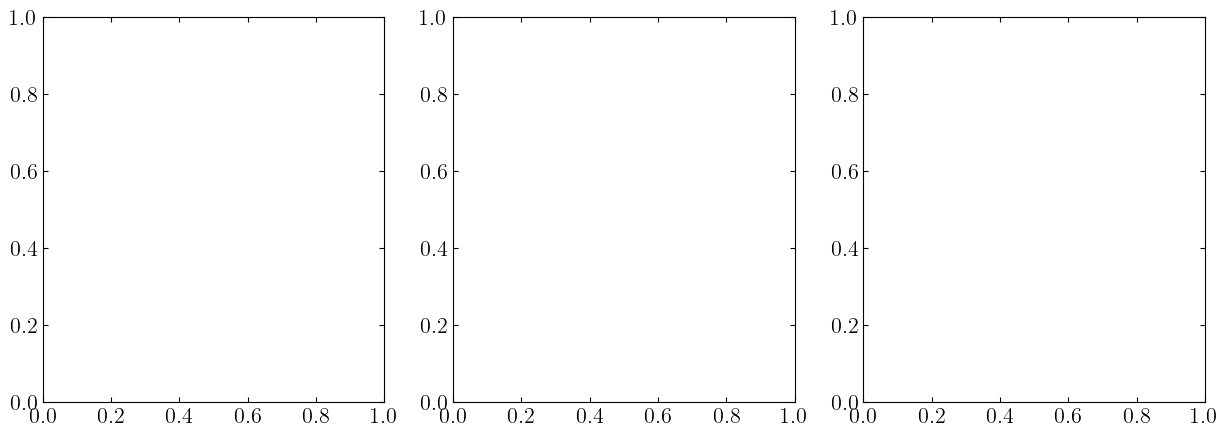

In [ ]:
f,ax = plt.subplots(1,3, figsize=(15,5))

In [ ]:
if SAVE:
    save_expressions(df_model_k,  f'k_{RUN_ID}')
    save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    save_expressions(df_model_R1, f'R1_{RUN_ID}')
    save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    save_expressions(df_model_C1, f'C1_{RUN_ID}')
    save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')